# Fine-Tuning GPT-4.1-mini for Text-to-Python Generation

**Goal:** Fine-tune GPT-4.1-mini to generate clean, correct Python code from natural language instructions — matching or beating GPT-5.4 quality at a fraction of the cost.

**The challenge:** Fine-tuning requires high-quality training data, but creating labeled datasets of programming tasks with correct solutions is expensive and time-consuming. We solve this using **NVIDIA Data Designer** to generate diverse, quality-scored synthetic data, and **Azure AI Foundry** to train, deploy, and evaluate the model.

**What you'll learn:**
1. How to use NVIDIA Data Designer to generate synthetic training data
2. How to filter and curate data for maximum fine-tuning impact
3. How to fine-tune, deploy, and evaluate models on Azure AI Foundry
4. The hyperparameter recipe that beats the teacher model

| Step | What | Tool |
|------|------|------|
| 1 | Setup & configuration | Azure AI Foundry SDK |
| 2 | Generate synthetic training data | NVIDIA Data Designer |
| 3 | Score, filter & split data | Data Designer judges + Python |
| 4 | Baseline evaluation | Azure AI Foundry (inference) |
| 5 | Fine-tune GPT-4.1-mini | Azure AI Foundry (training API) |
| 6 | Deploy & evaluate fine-tuned model | Azure AI Foundry (deployment + inference) |
| 7 | Compare results | Python analysis |
| 8 | Analyze training curve | GPT-5.4 as AI research assistant |

## 1. Setup & Configuration

Before we begin, we need:
- An **MicrosoftFoundry** resource with `gpt-5.4` and `gpt-4.1-mini` deployed
- The **NVIDIA Data Designer** SDK (`pip install data-designer`)
- The **OpenAI Python SDK** (`pip install openai`)

We use the OpenAI-compatible endpoint from Azure AI Foundry — this means the standard `openai` Python library works directly, no Azure-specific SDK needed.

In [ ]:
import json, time, re, os
from pathlib import Path
from openai import OpenAI

# Azure AI Foundry configuration
# Set these environment variables, or replace with your values
API_KEY = os.environ.get("AZURE_API_KEY", "<YOUR_AZURE_API_KEY>")
OPENAI_BASE_URL = os.environ.get(
    "AZURE_OPENAI_BASE_URL",
    "https://<YOUR_RESOURCE_NAME>.openai.azure.com/openai/v1",
).rstrip("/") + "/"
PROJECT_ENDPOINT = os.environ.get(
    "AZURE_PROJECT_ENDPOINT",
    "https://<YOUR_RESOURCE_NAME>.services.ai.azure.com/api/projects/<YOUR_PROJECT_NAME>",
).rstrip("/")

# Deployment names (override if your deployment names differ from the model names)
MODEL_54_DEPLOYMENT = os.environ.get("AZURE_GPT54_DEPLOYMENT", "gpt-5.4")
MODEL_41_MINI_DEPLOYMENT = os.environ.get("AZURE_GPT41MINI_DEPLOYMENT", "gpt-4.1-mini")

# Azure subscription details (used later for ARM deployments)
AZURE_SUBSCRIPTION_ID = os.environ.get("AZURE_SUBSCRIPTION_ID", "<YOUR_SUBSCRIPTION_ID>")
AZURE_RESOURCE_GROUP = os.environ.get("AZURE_RESOURCE_GROUP", "<YOUR_RESOURCE_GROUP>")
AZURE_ACCOUNT_NAME = os.environ.get("AZURE_ACCOUNT_NAME", "<YOUR_RESOURCE_NAME>")

# Use the direct Azure OpenAI endpoint for inference and Data Designer generation.
client = OpenAI(base_url=OPENAI_BASE_URL, api_key=API_KEY, timeout=120)

# Paths
ARTIFACT_PATH = Path("artifacts")

ARTIFACT_PATH.mkdir(exist_ok=True)
print(f"GPT-5.4 deployment: {MODEL_54_DEPLOYMENT}")

print(f"Using Azure OpenAI endpoint: {OPENAI_BASE_URL}")
print("✅ Setup complete")

✅ Setup complete
Using Azure OpenAI endpoint: https://<YOUR_RESOURCE_NAME>.openai.azure.com/openai/v1/
GPT-5.4 deployment: gpt-5.4


## 2. Generate Training Data with Data Designer

### Why synthetic data?

For fine-tuning, we need hundreds to thousands of high-quality (instruction, code) pairs. Manually writing these is expensive and slow. **NVIDIA Data Designer** solves this by orchestrating an LLM to generate diverse, quality-scored training examples automatically.

### What is Data Designer?

[NVIDIA Data Designer](https://developer.nvidia.com/data-designer) is an open-source SDK for generating synthetic datasets. It uses a pipeline architecture:

- **Sampler columns** — Control diversity by defining categories (industries, complexity levels, code concepts) that steer generation toward balanced coverage
- **LLM columns** — Generate content using configurable models with different temperature/inference settings  
- **Judge columns** — Automatically score each example on quality dimensions (relevance, style, readability, efficiency)
- **Validator columns** — Check structural correctness (e.g., Python syntax validation via AST parsing)
- **Schema transform** — Convert generated data into the format required by the training API (chat messages JSONL)

### What is distillation?

We're performing **model distillation** — training a smaller, cheaper "student" model (GPT-4.1-mini) to replicate the behavior of a larger, more capable "teacher" model (GPT-5.4). The teacher generates the training examples, and the student learns from them. The result: teacher-quality output at student-model cost and latency.

### 2.1 Configure the model provider

We point Data Designer at our Azure AI Foundry endpoint. We configure **two model aliases** with different temperatures:
- **High temperature (1.0)** for instruction generation — produces diverse, creative task descriptions
- **Low temperature (0.4)** for code generation and judging — produces reliable, correct code

In [24]:
import sys
import data_designer.config as dd
from data_designer.interface import DataDesigner
from data_designer.engine.validators.python import PythonValidator, RECORD_ID_COLUMN_NAME

# Helpful on Windows when generated code contains non-ASCII characters.
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

# Patch Data Designer's Python validator to write temp files as UTF-8.
def _write_code_to_file_utf8(self, row, code_column: str, path: str) -> None:
    file_path = f"{path}/{self._get_module_name(row[RECORD_ID_COLUMN_NAME], code_column)}.py"
    with open(file_path, "w", encoding="utf-8", errors="replace", newline="\n") as file:
        value = row[code_column]
        file.write("" if value is None else str(value))

PythonValidator._write_code_to_file = _write_code_to_file_utf8

# Model provider — point Data Designer at the direct Azure OpenAI endpoint
azure_provider = dd.ModelProvider(
    name="azure-openai",
    endpoint=OPENAI_BASE_URL.rstrip("/"),
    provider_type="openai",
    api_key=API_KEY,
)

# Two model configs: creative (high temp) for instructions, precise (low temp) for code.
# skip_health_check=True avoids the false-negative preflight failure seen with this endpoint/model combo.
model_configs = [
    dd.ModelConfig(
        alias="gpt-5.4",
        model=MODEL_54_DEPLOYMENT,
        provider="azure-openai",
        skip_health_check=True,
        inference_parameters=dd.ChatCompletionInferenceParams(
            temperature=1.0,
            top_p=1.0,
            timeout=180,
            max_parallel_requests=2,
            extra_body={"max_completion_tokens": 2048},
        ),
    ),
    dd.ModelConfig(
        alias="gpt-5.4-code",
        model=MODEL_54_DEPLOYMENT,
        provider="azure-openai",
        skip_health_check=True,
        inference_parameters=dd.ChatCompletionInferenceParams(
            temperature=0.4,
            top_p=0.95,
            timeout=180,
            max_parallel_requests=2,
            extra_body={"max_completion_tokens": 4096},
        ),
    ),
]

designer = DataDesigner(artifact_path=ARTIFACT_PATH, model_providers=[azure_provider])
config = dd.DataDesignerConfigBuilder(model_configs=model_configs)
print("✅ Data Designer initialized against Azure OpenAI")
print("✅ Patched Python validation temp files to use UTF-8")

✅ Data Designer initialized against Azure OpenAI
✅ Patched Python validation temp files to use UTF-8


In [25]:
# Quick connectivity probe for the teacher deployment via the Azure OpenAI endpoint
try:
    probe = client.chat.completions.create(
        model=MODEL_54_DEPLOYMENT,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "Reply with exactly: ok"},
        ],
        temperature=0,
        extra_body={"max_completion_tokens": 8},
    )
    print(f"✅ Connectivity check passed for {MODEL_54_DEPLOYMENT}")
    print(f"Endpoint: {OPENAI_BASE_URL}")
    print(probe.choices[0].message.content)
except Exception as e:
    print(f"❌ Connectivity check failed for {MODEL_54_DEPLOYMENT}")
    print(f"Endpoint: {OPENAI_BASE_URL}")
    print(type(e).__name__, e)

✅ Connectivity check passed for gpt-5.4
Endpoint: https://<YOUR_RESOURCE_NAME>.openai.azure.com/openai/v1/
ok


### Optional smoke test

After running the sampler, LLM, judge, and schema cells below, run the next cell to verify two things before launching a large dataset job:
1. Unicode validation works correctly on Windows
2. A one-record generation completes successfully

In [26]:
# Optional smoke test (run this after the sampler, LLM, judge, and schema cells below)
if not getattr(config, "_column_configs", {}):
    print("ℹ️ Run the configuration cells below first, then rerun this smoke test.")
else:
    unicode_validation = PythonValidator(
        dd.CodeValidatorParams(code_lang=dd.CodeLang.PYTHON)
    ).run_validation([
        {"code": "def circle_area(r):\n    σ = 3.14159\n    return σ * r**2\n"}
    ])
    print(f"✅ Unicode validation smoke test passed: {unicode_validation.data[0].is_valid}")

    smoke_test = designer.create(config, num_records=1)
    print(f"✅ One-record smoke test dataset created: {smoke_test.artifact_storage.final_dataset_path}")

ℹ️ Run the configuration cells below first, then rerun this smoke test.


### 2.2 Define diversity steering columns

Sampler columns control the **distribution of generated examples**. Without them, a language model tends to generate repetitive, similar examples. By sampling across industries, complexity levels, and coding concepts, we ensure the training data covers a wide range of realistic use cases.

The `SUBCATEGORY` sampler creates **hierarchical diversity** — e.g., Healthcare → EHR Systems, Finance → Fraud Detection — so the model learns to write code for many different domains.

In [27]:
# ── Diversity steering columns ──
config.add_column(dd.SamplerColumnConfig(
    name="industry_sector",
    sampler_type=dd.SamplerType.CATEGORY,
    params=dd.CategorySamplerParams(
        values=["Healthcare", "Finance", "Technology"],
    ),
))

config.add_column(dd.SamplerColumnConfig(
    name="topic",
    sampler_type=dd.SamplerType.SUBCATEGORY,
    params=dd.SubcategorySamplerParams(
        category="industry_sector",
        values={
            "Healthcare": [
                "Electronic Health Records (EHR) Systems",
                "Telemedicine Platforms",
                "AI-Powered Diagnostic Tools",
            ],
            "Finance": [
                "Fraud Detection Software",
                "Automated Trading Systems",
                "Personal Finance Apps",
            ],
            "Technology": [
                "Cloud Computing Platforms",
                "AI and Machine Learning Platforms",
                "DevOps and CI/CD Tools",
            ],
        },
    ),
))

config.add_column(dd.SamplerColumnConfig(
    name="code_complexity",
    sampler_type=dd.SamplerType.CATEGORY,
    params=dd.CategorySamplerParams(values=["Beginner", "Intermediate", "Advanced"]),
))

config.add_column(dd.SamplerColumnConfig(
    name="code_concept",
    sampler_type=dd.SamplerType.SUBCATEGORY,
    params=dd.SubcategorySamplerParams(
        category="code_complexity",
        values={
            "Beginner": ["Variables", "Data Types", "Functions", "Loops", "Classes"],
            "Intermediate": ["List Comprehensions", "OOP", "Lambda Functions", "Web Frameworks", "Pandas"],
            "Advanced": ["Multithreading", "Context Managers", "Generators"],
        },
    ),
))

config.add_column(dd.SamplerColumnConfig(
    name="instruction_phrase",
    sampler_type=dd.SamplerType.CATEGORY,
    params=dd.CategorySamplerParams(
        values=[
            "Write a function that",
            "Create a class that",
            "Implement a script",
            "Can you create a function",
            "Develop a module that",
        ],
    ),
))

print("✅ Sampler columns configured (3 industries × 3 topics × 3 complexities × 5 concepts)")

✅ Sampler columns configured (3 industries × 3 topics × 3 complexities × 5 concepts)


### 2.3 Define LLM generation columns

This is where the actual content generation happens. We use **two-stage generation**:

1. **Instruction generation** — GPT-5.4 at high temperature creates diverse, specific programming tasks. The prompt references the sampler columns (`{{ industry_sector }}`, `{{ code_complexity }}`, etc.) to steer the content.

2. **Code generation** — GPT-5.4 at low temperature writes clean, correct Python solutions. This uses the generated instruction (`{{ instruction }}`) as input, creating a natural (instruction → code) pair.

The key insight: separating instruction and code generation with different temperatures gives us **diverse tasks with reliable solutions**.

In [28]:
# ── LLM columns: instruction generation + code generation ──
config.add_column(dd.LLMTextColumnConfig(
    name="instruction",
    model_alias="gpt-5.4",
    system_prompt="You are an expert at generating clear and specific programming tasks.",
    prompt=(
        'Generate an instruction to create Python code that solves a specific problem.\n'
        'The instruction should begin with: "{{ instruction_phrase }}".\n\n'
        'Guidelines:\n'
        '* Industry Relevance: Pertains to {{ industry_sector }} / {{ topic }}.\n'
        '* Code Complexity: Tailored to {{ code_complexity }} level using {{ code_concept }}.\n'
        '* Clarity: Clear, unambiguous, with sufficient context.\n'
    ),
))

config.add_column(dd.LLMCodeColumnConfig(
    name="code_implementation",
    model_alias="gpt-5.4-code",
    code_lang=dd.CodeLang.PYTHON,
    system_prompt=(
        "You are an expert Python programmer. You respond ONLY with Python code. "
        "Do NOT include any explanatory text. Wrap your response in a ```python code block."
    ),
    prompt=(
        "Write Python code for the following instruction:\n"
        "Instruction: {{ instruction }}\n\n"
        "Guidelines:\n"
        "* Clean, complete, self-contained, and correct code.\n"
        "* Import any necessary libraries.\n"
        "* Code complexity: {{ code_complexity }} level using {{ code_concept }}.\n"
        "* Return ONLY Python code inside a ```python block.\n"
    ),
))

print("✅ LLM columns configured (instruction + code generation)")

✅ LLM columns configured (instruction + code generation)


### 2.4 Add quality judging and syntax validation

Every generated example gets **automatically scored** on four dimensions:
- **Relevance** — Does the code actually solve the stated task?
- **Pythonic** — Does it follow Python idioms and best practices?
- **Readability** — Is it well-formatted and maintainable?
- **Efficiency** — Does it use appropriate algorithms and data structures?

Each dimension is scored 0-4, giving us a fine-grained quality signal we can use for filtering.

Additionally, the **code validator** runs the generated Python through AST parsing to catch syntax errors — ensuring every training example is at least syntactically valid.

In [29]:
# ── Quality judge + syntax validator ──
python_scoring = [
    dd.Score(name="Relevance", description="Adherence to instructions",
             options={4: "Perfectly meets requirements.", 3: "Meets most requirements.",
                      2: "Moderate deviation.", 1: "Significant deviations.", 0: "Does not adhere."}),
    dd.Score(name="Pythonic", description="Pythonic code and best practices",
             options={4: "Exemplifies Pythonic principles.", 3: "Closely follows conventions.",
                      2: "Generally follows conventions.", 1: "Loosely follows conventions.", 0: "Not Pythonic."}),
    dd.Score(name="Readability", description="Readability and maintainability",
             options={4: "Excellently formatted, follows PEP 8.", 3: "Well-formatted and readable.",
                      2: "Somewhat readable.", 1: "Minimal formatting.", 0: "Unreadable."}),
    dd.Score(name="Efficiency", description="Efficiency and performance",
             options={4: "Highly efficient.", 3: "Efficient with minor optimization areas.",
                      2: "Moderately efficient.", 1: "Poor efficiency.", 0: "Highly inefficient."}),
]

JUDGE_TEMPLATE = (
    "You are an expert Python programmer and code reviewer.\n\n"
    "Score the Generated Python Code based on the Natural Language Prompt.\n\n"
    "Natural Language Prompt:\n{{ instruction }}\n\n"
    "Generated Python Code:\n{{ code_implementation }}"
)

config.add_column(dd.LLMJudgeColumnConfig(
    name="code_judge_result",
    model_alias="gpt-5.4-code",
    prompt=JUDGE_TEMPLATE,
    scores=python_scoring,
))

config.add_column(dd.ValidationColumnConfig(
    name="code_validity_result",
    validator_type=dd.ValidatorType.CODE,
    target_columns=["code_implementation"],
    validator_params=dd.CodeValidatorParams(code_lang=dd.CodeLang.PYTHON),
    batch_size=100,
))

print("✅ Quality judge (4 dimensions) + syntax validator configured")

✅ Quality judge (4 dimensions) + syntax validator configured


### 2.5 Schema transform — format for fine-tuning

Azure AI Foundry expects training data in **chat messages JSONL format**: each example is a JSON object with a `messages` array containing `system`, `user`, and `assistant` messages.

The schema transform converts Data Designer's columnar output into this format automatically. The **system prompt** is critical — it must be consistent across training and inference, as it sets the model's persona and behavioral expectations.

In [30]:
# ── Schema transform: convert to chat messages JSONL format ──
SYSTEM_PROMPT = (
    "You are a helpful assistant that writes clean, well-structured "
    "Python code to solve the user's request."
)

config.add_processor(dd.SchemaTransformProcessorConfig(
    name="chat_messages_jsonl",
    template={
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "{{ instruction }}"},
            {"role": "assistant", "content": "{{ code_implementation }}"},
        ],
    },
))

print("✅ Schema transform configured → chat messages JSONL format")

✅ Schema transform configured → chat messages JSONL format


### Generate the dataset

This generates examples in parallel using GPT-5.4. Each example goes through:
1. **Instruction generation** (high temperature for diversity)
2. **Code generation** (low temperature for correctness)
3. **Quality judging** (4-dimension scoring)
4. **Syntax validation** (Python AST parsing)

⏱️ ~500 examples takes about 10-15 minutes.

In [ ]:
# Generate examples
NUM_RECORDS = int(os.environ.get("NUM_RECORDS", "2000"))  # override for quick tests if needed


def latest_artifact_dir(root: Path):
    candidates = sorted(Path(root).glob("dataset*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


print(f"Generating {NUM_RECORDS} examples with GPT-5.4 deployment '{MODEL_54_DEPLOYMENT}'...")
results = None

try:
    results = designer.create(config, num_records=NUM_RECORDS)
    print(f"✅ Generation complete! Saved to: {results.artifact_storage.final_dataset_path}")
except Exception as e:
    latest = latest_artifact_dir(ARTIFACT_PATH)
    print(f"❌ Dataset generation did not fully finish: {e}")
    if latest:
        print(f"Latest artifact directory: {latest}")
        for name in ("parquet-files", "processors-files", "tmp-partial-parquet-files"):
            path = latest / name
            if path.exists():
                print(f"Found partial output: {path}")
    print("You can still run the next cell to try recovering the latest saved parquet files.")

[14:50:26] [INFO] 🎨 Creating Data Designer dataset


[14:50:26] [INFO] 📂 Dataset path 'artifacts\\dataset' already exists. Dataset from this session
		     will be saved to 'artifacts\\dataset_04-09-2026_145026' instead.
[14:50:26] [INFO] ✅ Validation passed
[14:50:26] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph
[14:50:26] [INFO] 🩺 Running health checks for models...
[14:50:26] [INFO]   |-- ⏭️  Skipping health check for model alias 'gpt-5.4' (skip_health_check=True)
[14:50:26] [INFO]   |-- ⏭️  Skipping health check for model alias 'gpt-5.4-code' (skip_health_check=True)


Generating 100 examples with GPT-5.4 deployment 'gpt-5.4'...


[14:50:26] [INFO] ⏳ Processing batch 1 of 1
[14:50:26] [INFO] 🎲 Preparing samplers to generate 100 records across 5 columns
[14:50:26] [INFO] 📝 llm-text model config for column 'instruction'
[14:50:26] [INFO]   |-- model: 'gpt-5.4'
[14:50:26] [INFO]   |-- model alias: 'gpt-5.4'
[14:50:26] [INFO]   |-- model provider: 'azure-openai'
[14:50:26] [INFO]   |-- inference parameters:
[14:50:26] [INFO]   |  |-- generation_type=chat-completion
[14:50:26] [INFO]   |  |-- max_parallel_requests=2
[14:50:26] [INFO]   |  |-- timeout=180
[14:50:26] [INFO]   |  |-- extra_body={'max_completion_tokens': 2048}
[14:50:26] [INFO]   |  |-- temperature=1.00
[14:50:26] [INFO]   |  |-- top_p=1.00
[14:50:26] [INFO] ⚡️ Processing llm-text column 'instruction' with 2 concurrent workers
[14:50:26] [INFO] ⏱️ llm-text column 'instruction' will report progress every 10 records
[14:51:06] [INFO]   |-- 😴 llm-text column 'instruction' progress: 10/100 (10%) complete, 10 ok, 0 failed, 0.25 rec/s, eta 354.8s
[14:51:37] [I

✅ Generation complete! Saved to: artifacts\dataset_04-09-2026_145026\parquet-files


## 3. Score, Filter & Create Train/Val Split

### Why filter?

Even with a strong generator model, not every synthetic example is good enough for training. Some may have:
- Incorrect or incomplete code
- Vague or ambiguous instructions
- Code that doesn't match the instruction
- Near-duplicate content

Our filtering pipeline removes these low-quality examples. In practice, we find **~70-80% of generated examples pass** our quality threshold, so generating 2,000 examples typically yields 1,500+ usable training examples.

### Why an independent validation set?

The validation set must have **zero overlap** with the training data. Even partial overlap (shared prompts with different solutions) inflates eval scores and gives a false sense of model quality. We hold out a clean 5% split that we never train on.

In [47]:
# Load the generated dataset with quality scores.
# If the generation cell ended with a late-stage error, recover the latest complete saved parquet artifacts from disk.
import pandas as pd

REQUIRED_DATASET_COLUMNS = {
    "instruction",
    "code_implementation",
    "code_judge_result",
    "code_validity_result",
}


def load_best_saved_dataset(artifact_root: Path):
    """Load the newest artifact that contains ALL required columns (including judge scores).
    Raises RuntimeError if no complete artifact is found."""
    artifact_dirs = sorted(Path(artifact_root).glob("dataset*"), key=lambda p: p.stat().st_mtime, reverse=True)

    for artifact_dir in artifact_dirs:
        for subdir_name in ("parquet-files", "tmp-partial-parquet-files"):
            subdir = artifact_dir / subdir_name
            parquet_files = sorted(subdir.glob("*.parquet"))
            if not parquet_files:
                continue
            try:
                df = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
            except Exception:
                continue

            if REQUIRED_DATASET_COLUMNS.issubset(df.columns):
                return artifact_dir, df

    # No complete artifact found — report what's available so the user can debug.
    partial_info = []
    for artifact_dir in artifact_dirs:
        for subdir_name in ("parquet-files", "tmp-partial-parquet-files"):
            subdir = artifact_dir / subdir_name
            parquet_files = sorted(subdir.glob("*.parquet"))
            if parquet_files:
                try:
                    df = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
                    partial_info.append(f"  {subdir}: {len(df)} rows, columns={list(df.columns)}")
                except Exception:
                    partial_info.append(f"  {subdir}: could not read")

    msg = (
        "No artifact with all required columns was found.\n"
        f"Required columns: {REQUIRED_DATASET_COLUMNS}\n"
    )
    if partial_info:
        msg += "Partial artifacts found (missing judge/validity columns):\n" + "\n".join(partial_info)
    else:
        msg += "No parquet files found at all under the artifacts folder."
    raise RuntimeError(msg)


def extract_avg_quality(judge_value):
    if isinstance(judge_value, str):
        try:
            judge_value = json.loads(judge_value) if judge_value else {}
        except json.JSONDecodeError:
            judge_value = {}

    if isinstance(judge_value, dict):
        # Newer Data Designer format: each rubric key maps to {reasoning, score}.
        nested_scores = [
            value.get("score")
            for value in judge_value.values()
            if isinstance(value, dict) and isinstance(value.get("score"), (int, float))
        ]
        if nested_scores:
            return sum(nested_scores) / len(nested_scores)

        # Older fallback format: {"scores": {...}}
        scores = judge_value.get("scores", {})
        if isinstance(scores, dict) and scores:
            numeric_scores = [v for v in scores.values() if isinstance(v, (int, float))]
            if numeric_scores:
                return sum(numeric_scores) / len(numeric_scores)

    return 0.0


def extract_is_valid(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        text = value.strip()
        if text.lower() in {"true", "false"}:
            return text.lower() == "true"
        try:
            value = json.loads(text)
        except json.JSONDecodeError:
            return True
    if isinstance(value, dict):
        return bool(value.get("is_valid", True))
    return True


results_obj = globals().get("results")
messages_df = None
raw_df = None

if results_obj is not None:
    try:
        candidate_df = results_obj.load_dataset()
        if REQUIRED_DATASET_COLUMNS.issubset(candidate_df.columns):
            raw_df = candidate_df
            try:
                messages_df = results_obj.load_processor_dataset("chat_messages_jsonl")
            except Exception:
                messages_df = None
        else:
            missing = REQUIRED_DATASET_COLUMNS - set(candidate_df.columns)
            raise RuntimeError(
                f"The in-memory `results` object is missing required columns: {missing}. "
                "The generation pipeline may not have completed the judge/validation stages. "
                "Re-run the generation cell and ensure all pipeline stages finish."
            )
    except RuntimeError:
        raise
    except Exception:
        raw_df = None

if raw_df is None:
    recovered_dir, raw_df = load_best_saved_dataset(ARTIFACT_PATH)
    print(f"⚠️ Recovered dataset from saved artifacts in: {recovered_dir}")

# Final guard: every required column must be present.
missing_cols = REQUIRED_DATASET_COLUMNS - set(raw_df.columns)
if missing_cols:
    raise RuntimeError(
        f"Loaded dataset is missing required columns: {missing_cols}. "
        "The generation pipeline must complete the judge and validation stages before filtering. "
        "Re-run the generation cell."
    )

print(f"Generated: {len(raw_df)} examples")
print("\nQuality score distribution:")

raw_df = raw_df.copy()
raw_df["avg_quality"] = raw_df["code_judge_result"].apply(extract_avg_quality)
valid_mask = raw_df["code_validity_result"].apply(extract_is_valid)

QUALITY_THRESHOLD = 3.0  # Average ≥ 3/4 on judge scores
has_quality_signal = raw_df["avg_quality"].gt(0).any()

if not has_quality_signal:
    raise RuntimeError(
        "No usable judge scores found in `code_judge_result`. "
        "Every row has avg_quality=0, which means the judge column data is corrupt or in an unrecognized format. "
        "Inspect a sample value:\n"
        f"  {raw_df['code_judge_result'].iloc[0]!r}"
    )

mask = (raw_df["avg_quality"] >= QUALITY_THRESHOLD) & valid_mask
filtered_df = raw_df.loc[mask].copy()
print(
    f"After quality filter (≥{QUALITY_THRESHOLD}/4 avg): "
    f"{len(filtered_df)}/{len(raw_df)} ({len(filtered_df) / len(raw_df) * 100:.0f}%)"
)

if filtered_df.empty:
    raise RuntimeError(
        f"No rows passed the quality filter (threshold={QUALITY_THRESHOLD}). "
        f"Score distribution: min={raw_df['avg_quality'].min():.2f}, "
        f"max={raw_df['avg_quality'].max():.2f}, "
        f"mean={raw_df['avg_quality'].mean():.2f}. "
        "Consider lowering QUALITY_THRESHOLD or re-generating with a different judge model."
    )

# Dedup by normalized instruction text.
before_dedup = len(filtered_df)
dedup_key = filtered_df["instruction"].fillna("").astype(str).str.strip()
if (dedup_key != "").any():
    filtered_df = (
        filtered_df.assign(_dedup_key=dedup_key.str.lower().str[:160])
        .drop_duplicates(subset="_dedup_key")
        .drop(columns="_dedup_key")
        .reset_index(drop=True)
    )
else:
    filtered_df = filtered_df.reset_index(drop=True)
print(f"After dedup: {len(filtered_df)} unique examples (removed {before_dedup - len(filtered_df)})")

Generated: 91 examples

Quality score distribution:
After quality filter (≥3.0/4 avg): 88/91 (97%)
After dedup: 88 unique examples (removed 0)


### Create train/val split

We hold out 5% of examples as an independent validation set. This validation set will be used to:
1. **Monitor training loss** — Azure reports validation loss during fine-tuning
2. **Evaluate model quality** — we'll run our correctness/conciseness grader on it
3. **Compare against baselines** — same prompts, same grading, fair comparison

The key requirement is **zero overlap** between training and validation data.

In [44]:
# Create train/val split — hold out ~5% for independent validation
from sklearn.model_selection import train_test_split

num_examples = len(filtered_df)
if num_examples < 2:
    raise ValueError(
        "Not enough usable examples remain after filtering to create a train/validation split. "
        "Rerun the previous cell and inspect its fallback/filter summary."
    )

val_size = max(1, int(round(num_examples * 0.05)))
val_size = min(val_size, num_examples - 1)

train_idx, val_idx = train_test_split(
    filtered_df.index, test_size=val_size, random_state=42
)

# Export to JSONL in chat messages format
SYSTEM_PROMPT = "You are a helpful assistant that writes clean, well-structured Python code to solve the user's request."


def to_messages(row):
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["instruction"]},
            {"role": "assistant", "content": row["code_implementation"]},
        ]
    }


train_records = [to_messages(filtered_df.loc[i]) for i in train_idx]
val_records = [to_messages(filtered_df.loc[i]) for i in val_idx]

TRAIN_FILE = "training_data.jsonl"
VAL_FILE = "validation_data.jsonl"

with open(TRAIN_FILE, "w", encoding="utf-8") as f:
    for r in train_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with open(VAL_FILE, "w", encoding="utf-8") as f:
    for r in val_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"✅ Training set: {len(train_records)} examples → {TRAIN_FILE}")
print(f"✅ Validation set: {len(val_records)} examples → {VAL_FILE}")

✅ Training set: 84 examples → training_data.jsonl
✅ Validation set: 4 examples → validation_data.jsonl


## 4. Upload Data & Baseline Evaluation

### Why baseline before training?

Before fine-tuning, we need to know **how good the models already are** at our task. This gives us:
- A **ceiling** (GPT-5.4) — the generator model's quality is the best we can hope for through distillation
- A **floor** (GPT-4.1-mini base) — what the model can do without any task-specific training
- A **clear improvement target** — fine-tuning should close the gap between floor and ceiling

### Our grading methodology

We use the **Azure AI Foundry Evals SDK** to run evaluations. For each model, the SDK:
1. **Calls the model** via `azure_ai_target_completions` with the same system prompt and validation prompts used in training
2. **Grades each response** using a registered code-based Python evaluator that calls GPT-5.4 as the judge
3. **Scores two dimensions**: Correctness (1-10) and Conciseness (1-10), returning the combined average

We also track **Pass@8** — the percentage of responses scoring 8+ on the combined metric — as a practical "would you accept this code?" measure.

In [45]:
# Upload training and validation files
print("Uploading files to Azure AI Foundry...")
train_upload = client.files.create(file=open(TRAIN_FILE, "rb"), purpose="fine-tune")
val_upload = client.files.create(file=open(VAL_FILE, "rb"), purpose="fine-tune")
print(f"  Training file:   {train_upload.id}")
print(f"  Validation file: {val_upload.id}")

# Load validation data for evaluation
with open(VAL_FILE) as f:
    val_data = [json.loads(l) for l in f]

val_prompts = [next(m["content"] for m in ex["messages"] if m["role"] == "user") for ex in val_data]
val_references = [next(m["content"] for m in ex["messages"] if m["role"] == "assistant") for ex in val_data]
val_system = [next(m["content"] for m in ex["messages"] if m["role"] == "system") for ex in val_data]

print(f"\n✅ {len(val_prompts)} validation prompts ready for evaluation")

Uploading files to Azure AI Foundry...
  Training file:   file-abc123train
  Validation file: file-abc123val

✅ 4 validation prompts ready for evaluation


### Define evaluation functions (Foundry Evals SDK)

We use the **Azure AI Foundry Evals SDK** (`azure-ai-projects` + OpenAI evals API) to evaluate each model. The SDK handles:

1. **Model targeting** — The `azure_ai_target_completions` data source calls each model with our validation prompts and system message, so we don't need manual generation loops.

2. **Grading** — We register a **code-based Python grader** that scores each response on correctness (1-10) and conciseness (1-10) by calling GPT-5.4 as the judge. The grader also computes Pass@8 and code length.

3. **Run management** — The SDK creates evaluation runs, polls for completion, and collects per-item results with a report URL for the Foundry portal.

This replaces the hand-rolled generation + grading loop with the official SDK pattern, giving us portal integration and reproducible eval runs.

In [ ]:
# ── Evaluation via Foundry Evals SDK ──
from openai import AzureOpenAI
from openai.types.eval_create_params import DataSourceConfigCustom
from openai.types.evals.create_eval_jsonl_run_data_source_param import (
    CreateEvalJSONLRunDataSourceParam,
    SourceFileContent,
    SourceFileContentContent,
)

# Evals API with azure_ai_target_completions requires the Foundry project endpoint.
# AzureOpenAI sends the key via the 'api-key' header — no credential wrappers needed.
eval_client = AzureOpenAI(
    base_url=OPENAI_BASE_URL.rstrip("/").removesuffix("/v1"),
    api_key=API_KEY,
    api_version="2025-03-01-preview",
)

# ── Data source config (shared across all eval runs) ──
data_source_config = DataSourceConfigCustom(
    type="custom",
    item_schema={
        "type": "object",
        "properties": {
            "query": {"type": "string"},
            "ground_truth": {"type": "string"},
            "system_prompt": {"type": "string"},
        },
        "required": ["query", "ground_truth"],
    },
    include_sample_schema=True,
)

# ── Testing criteria: two score_model graders using GPT-5.4 as judge ──
# Each score_model grader must return a single integer. Use separate focused prompts
# to avoid any literal {{ }} that the eval engine would parse as template references.

CORRECTNESS_PROMPT = (
    "You are evaluating Python code written to solve a programming task.\n\n"
    "## Task\n{{item.query}}\n\n"
    "## Reference Solution\n{{item.ground_truth}}\n\n"
    "## Candidate Code\n{{sample.output_text}}\n\n"
    "Score ONLY correctness: does the candidate code correctly solve the task?\n"
    "- 9-10: Fully correct\n- 7-8: Mostly correct, minor issues\n"
    "- 5-6: Partially correct\n- 3-4: Major issues\n- 1-2: Fails entirely\n\n"
    "Respond with ONLY a single integer from 1 to 10."
)

CONCISENESS_PROMPT = (
    "You are evaluating Python code written to solve a programming task.\n\n"
    "## Task\n{{item.query}}\n\n"
    "## Reference Solution\n{{item.ground_truth}}\n\n"
    "## Candidate Code\n{{sample.output_text}}\n\n"
    "Score ONLY conciseness: is the code appropriately minimal and clean?\n"
    "- 9-10: Clean, minimal\n- 7-8: Reasonable length\n"
    "- 5-6: Somewhat verbose\n- 3-4: Very verbose\n- 1-2: Bloated\n\n"
    "Respond with ONLY a single integer from 1 to 10."
)

testing_criteria = [
    {
        "type": "score_model",
        "name": "correctness",
        "model": MODEL_54_DEPLOYMENT,
        "input": [
            {"role": "user", "content": CORRECTNESS_PROMPT},
        ],
        "range": [1, 10],
        "pass_threshold": 8,
    },
    {
        "type": "score_model",
        "name": "conciseness",
        "model": MODEL_54_DEPLOYMENT,
        "input": [
            {"role": "user", "content": CONCISENESS_PROMPT},
        ],
        "range": [1, 10],
        "pass_threshold": 8,
    },
]

# ── Build the inline JSONL content from val_prompts ──
eval_items = [
    {
        "item": {
            "query": val_prompts[i],
            "ground_truth": val_references[i],
            "system_prompt": val_system[i],
        }
    }
    for i in range(len(val_prompts))
]


def eval_model(name, model_name, temp=0.0):
    """Run a Foundry Evals SDK evaluation for a model on the validation set."""
    print(f"\n{'='*50} {name}")

    # Create the evaluation definition
    eval_object = eval_client.evals.create(
        name=f"text2py-{name}",
        data_source_config=data_source_config,
        testing_criteria=testing_criteria,  # type: ignore
    )
    print(f"  Eval created: {eval_object.id}")

    # Create the evaluation run with the model as target
    data_source = {
        "type": "completions",
        "source": {
            "type": "file_content",
            "content": [{"item": item["item"]} for item in eval_items],
        },
        "input_messages": {
            "type": "template",
            "template": [
                {"type": "message", "role": "system", "content": {"type": "input_text", "text": "{{item.system_prompt}}"}},
                {"type": "message", "role": "user", "content": {"type": "input_text", "text": "{{item.query}}"}},
            ],
        },
        "model": model_name,
        "sampling_params": {
            "temperature": temp,
            "max_completions_tokens": 16384,
        },
    }

    eval_run = eval_client.evals.runs.create(
        eval_id=eval_object.id,
        name=f"run-{name}",
        data_source=data_source,  # type: ignore
    )
    print(f"  Run created: {eval_run.id}")

    # Poll until complete
    while True:
        run = eval_client.evals.runs.retrieve(run_id=eval_run.id, eval_id=eval_object.id)
        if run.status in ("completed", "failed"):
            break
        print(f"  Status: {run.status}...")
        time.sleep(10)

    if run.status == "failed":
        # Print all available error details
        print(f"  ❌ Eval run failed")
        for attr in ("error", "error_message", "failure_reason"):
            val = getattr(run, attr, None)
            if val:
                print(f"  {attr}: {val}")
        # Dump all non-None fields for debugging
        run_dict = run.model_dump() if hasattr(run, "model_dump") else run.__dict__
        for k, v in run_dict.items():
            if v is not None and k not in ("id", "eval_id", "name", "status", "data_source", "created_at"):
                print(f"  run.{k} = {v}")

        # Check if there are any output items with error details
        try:
            output_items = list(eval_client.evals.runs.output_items.list(run_id=run.id, eval_id=eval_object.id))
            if output_items:
                print(f"  Output items: {len(output_items)}")
                oi0 = output_items[0]
                oi_dict = oi0.model_dump() if hasattr(oi0, "model_dump") else oi0.__dict__
                print(f"  First output item: {json.dumps(oi_dict, indent=2, default=str)[:2000]}")
        except Exception as e:
            print(f"  Could not retrieve output items: {e}")

        return {
            "correctness": 0, "conciseness": 0, "combined": 0,
            "pass_at_8": 0, "num_scored": 0, "report_url": "",
        }

    # Collect output items and parse per-grader scores
    output_items = list(eval_client.evals.runs.output_items.list(run_id=run.id, eval_id=eval_object.id))

    # Debug: print first output item structure
    if output_items:
        oi0 = output_items[0]
        oi_dict = oi0.model_dump() if hasattr(oi0, "model_dump") else oi0.__dict__
        print(f"  DEBUG first output item: {json.dumps(oi_dict, indent=2, default=str)[:1500]}")

    correctness_scores = []
    conciseness_scores = []
    for oi in output_items:
        for r in getattr(oi, "results", []):
            r_dict = r.model_dump() if hasattr(r, "model_dump") else (r if isinstance(r, dict) else r.__dict__)
            grader_name = r_dict.get("name", "")
            score = r_dict.get("score")
            if score is None:
                continue
            score = float(score)
            if grader_name == "correctness":
                correctness_scores.append(score)
            elif grader_name == "conciseness":
                conciseness_scores.append(score)

    num_scored = max(len(correctness_scores), len(conciseness_scores))
    avg_c = sum(correctness_scores) / len(correctness_scores) if correctness_scores else 0
    avg_k = sum(conciseness_scores) / len(conciseness_scores) if conciseness_scores else 0
    avg_combined = (avg_c + avg_k) / 2 if (correctness_scores and conciseness_scores) else 0
    p8 = sum(1 for s in correctness_scores if s >= 8) / len(correctness_scores) * 100 if correctness_scores else 0

    report_url = getattr(run, "report_url", "")

    result = {
        "correctness": round(avg_c, 2),
        "conciseness": round(avg_k, 2),
        "combined": round(avg_combined, 2),
        "pass_at_8": round(p8, 1),
        "num_scored": num_scored,
        "report_url": report_url,
    }
    print(f"  ✅ Correctness={avg_c:.1f}  Conciseness={avg_k:.1f}  Combined={avg_combined:.1f}  P@8={p8:.0f}%  Scored={num_scored}/{len(val_prompts)}")
    if report_url:
        print(f"  📊 Report: {report_url}")
    return result


✅ Foundry Evals SDK evaluation functions defined


### Run baseline evaluations

In [56]:
# Evaluate baselines
eval_results = {}

eval_results["GPT-5.4 (generator)"] = eval_model("GPT-5.4 (generator)", "gpt-5.4")
eval_results["GPT-4.1-mini (pre-FT)"] = eval_model("GPT-4.1-mini (pre-FT)", "gpt-4.1-mini")

print("\n" + "="*60)
print(f"{'Model':<25} {'Corr':>5} {'Conc':>5} {'Comb':>5} {'P@8':>5} {'Scored':>7}")
print("-"*60)
for name, r in eval_results.items():
    print(f"{name:<25} {r['correctness']:5.1f} {r['conciseness']:5.1f} {r['combined']:5.1f} {r['pass_at_8']:4.0f}% {r['num_scored']:>7}")

[20:54:08] [INFO] Request URL: 'http://169.254.169.254/metadata/identity/oauth2/token?api-version=REDACTED&resource=REDACTED'
Request method: 'GET'
Request headers:
    'User-Agent': 'azsdk-python-identity/1.25.3 Python/3.11.9 (Windows-10-10.0.26200-SP0)'
No body was attached to the request



================================================== GPT-5.4 (generator)


[20:54:10] [INFO] DefaultAzureCredential acquired a token from AzureCliCredential


  Eval created: eval_abc123example1
  Run created: evalrun_abc123run1
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  Status: in_progress...
  DEBUG first output item: {
  "id": "1",
  "created_at": 1775782639,
  "datasource_item": {
    "query": "Implement a script that simulates a simple AI-powered diagnostic helper for a healthcare clinic using Python functions. The program should ask the user to enter basic patient symptom information such as fever (yes/no), cough (yes/no), fatigue (yes/no), and oxygen level (integer). Create separate functions to collect input, evaluate the symptoms, and display a diagnostic 

## 5. Fine-Tune GPT-4.1-mini

### The winning hyperparameter recipe

Through systematic experimentation across 50+ training runs, we found the optimal configuration:

| Parameter | Value | Why |
|-----------|-------|-----|
| **Model** | `gpt-4.1-mini-2025-04-14` | Best balance of capability, cost, and fine-tuning robustness |
| **Epochs** | 1 | One pass captures all signal; more epochs overfit on synthetic data |
| **Learning rate** | 1.3× | Aggressive enough for single-pass learning, but not so high it destabilizes |
| **Batch size** | 1 | Maximum gradient updates per step for small datasets |
| **Training tier** | Developer Tier | 50% discount on training costs — ideal for experimentation |

**Key insight:** With high-quality synthetic data, less is more. One epoch with ~1,500 curated examples beats multi-epoch training on larger datasets. We tested 4,710 examples and performance actually *decreased* — quality of training data matters far more than quantity.

In [57]:
# Submit fine-tuning job
print("Submitting fine-tuning job...")

# Wait for files to be processed
time.sleep(10)

job = client.fine_tuning.jobs.create(
    model="gpt-4.1-mini-2025-04-14",
    training_file=train_upload.id,
    validation_file=val_upload.id,
    suffix="text2py-notebook",
    hyperparameters={
        "n_epochs": 1,
        "learning_rate_multiplier": 1.3,
        "batch_size": 1,
    },
    extra_body={"trainingType": "developerTier"},  # 50% discount on training costs
)

print(f"✅ Job submitted: {job.id}")
print(f"   Model: {job.model}")
print(f"   Status: {job.status}")

Submitting fine-tuning job...
✅ Job submitted: ftjob-abc123example
   Model: gpt-4.1-mini-2025-04-14
   Status: pending


In [ ]:
# Monitor training progress
print("Monitoring training progress...")
while True:
    job = client.fine_tuning.jobs.retrieve(job.id)
    print(f"  Status: {job.status}")

    if job.status == "succeeded":
        print(f"\n✅ Training complete!")
        print(f"   Fine-tuned model: {job.fine_tuned_model}")
        break
    elif job.status == "failed":
        print(f"\n❌ Training failed: {job.error}")
        break

    time.sleep(60)

Monitoring training progress...
  Status: pending | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Trained tokens: None
  Status: running | Train

### 5.1 Training Metrics

After training completes, we can download the training curve to verify healthy learning. Look for:
- **Training loss decreasing** — the model is learning from the data
- **Train/valid loss ratio < 2x** — no significant overfitting
- **Token accuracy increasing** — the model is getting better at predicting the correct tokens

The results file is a CSV with per-step metrics that we can analyze and plot.

Total steps: 84
Final train loss: 0.2115
Final train accuracy: 0.9101
Final valid loss: 0.2197
Overfit ratio: 1.0x ✅ Healthy


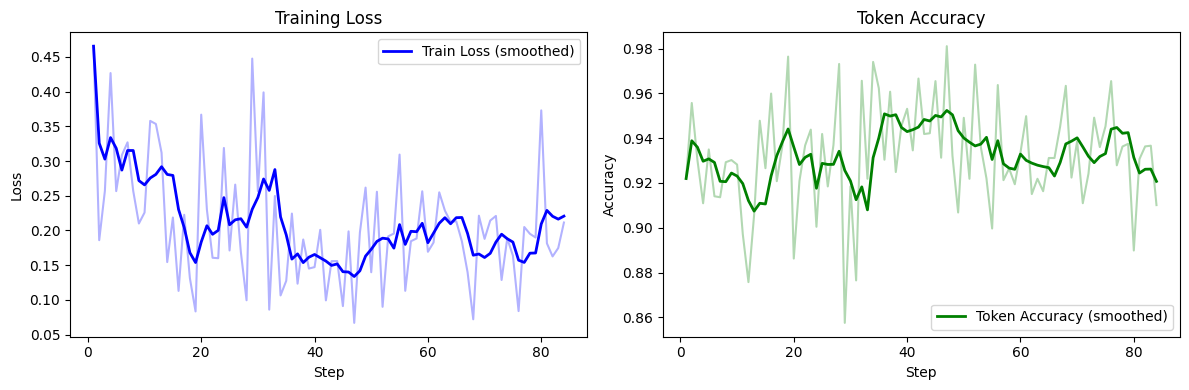

In [61]:
# Download and plot training metrics
import csv
from io import StringIO

if job.result_files:
    content = client.files.content(job.result_files[0])
    csv_text = content.text

    reader = csv.DictReader(StringIO(csv_text))
    rows = list(reader)

    steps = [int(r["step"]) for r in rows]
    train_loss = [float(r["train_loss"]) for r in rows]
    train_acc = [float(r["train_mean_token_accuracy"]) for r in rows]

    # Print summary
    print(f"Total steps: {len(rows)}")
    print(f"Final train loss: {train_loss[-1]:.4f}")
    print(f"Final train accuracy: {train_acc[-1]:.4f}")

    # Check for validation metrics at final step
    final = rows[-1]
    if final.get("valid_loss") and final["valid_loss"].strip():
        vl = float(final["valid_loss"])
        overfit_ratio = vl / train_loss[-1] if train_loss[-1] > 0 else 0
        print(f"Final valid loss: {vl:.4f}")
        print(f"Overfit ratio: {overfit_ratio:.1f}x {'✅ Healthy' if overfit_ratio < 2 else '⚠️ Overfitting'}")

    # Optional: plot if matplotlib available
    try:
        import matplotlib; matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(steps, train_loss, alpha=0.3, color='blue')
        # Rolling average
        window = max(1, len(steps) // 20)
        avg_loss = [sum(train_loss[max(0,i-window):i+1])/min(i+1,window+1) for i in range(len(train_loss))]
        ax1.plot(steps, avg_loss, color='blue', linewidth=2, label='Train Loss (smoothed)')
        ax1.set_xlabel('Step'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss'); ax1.legend()

        ax2.plot(steps, train_acc, alpha=0.3, color='green')
        avg_acc = [sum(train_acc[max(0,i-window):i+1])/min(i+1,window+1) for i in range(len(train_acc))]
        ax2.plot(steps, avg_acc, color='green', linewidth=2, label='Token Accuracy (smoothed)')
        ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy'); ax2.set_title('Token Accuracy'); ax2.legend()

        plt.tight_layout()
        plt.savefig('training_curve.png', dpi=100, bbox_inches='tight')
        plt.close()
        print('Saved training_curve.png')
    except ImportError:
        print("(matplotlib not available — skipping plot)")

## 6. Deploy & Evaluate the Fine-Tuned Model

### Deployment on Azure AI Foundry

Fine-tuned models are deployed as custom model deployments through the Azure Resource Manager (ARM) API. Once deployed, they're accessible via the same OpenAI-compatible inference API — your existing code works without changes.

**Azure AI Foundry** handles the full lifecycle:
- **Training** — Submit fine-tuning jobs via the OpenAI SDK
- **Hosting** — Deploy fine-tuned models with configurable capacity  
- **Inference** — Same API as base models, no code changes needed
- **Evaluation** — Use deployed models (including GPT-5.4) as automated graders

In [62]:
# Deploy the fine-tuned model
import subprocess, urllib.request, urllib.error

FT_MODEL = job.fine_tuned_model
DEPLOY_NAME = "mini-ft-text2py"
ARM_BASE = (
    "https://management.azure.com/subscriptions/{sub_id}"
    "/resourceGroups/{rg}"
    "/providers/Microsoft.CognitiveServices/accounts/{account}/deployments"
)

# Get ARM token
import shutil
AZ_CMD = shutil.which("az") or "az"
token = subprocess.run(
    [AZ_CMD, "account", "get-access-token", "--query", "accessToken", "-o", "tsv"],
    capture_output=True, text=True
).stdout.strip()

url = ARM_BASE.format(sub_id=AZURE_SUBSCRIPTION_ID, rg=AZURE_RESOURCE_GROUP, account=AZURE_ACCOUNT_NAME) + f"/{DEPLOY_NAME}?api-version=2024-10-01"

# Delete existing deployment if it exists (fine-tuned deployments cannot be updated in-place)
try:
    del_req = urllib.request.Request(url, method="DELETE",
                                     headers={"Authorization": f"Bearer {token}"})
    urllib.request.urlopen(del_req)
    print(f"Deleted existing deployment '{DEPLOY_NAME}', waiting for cleanup...")
    time.sleep(30)
except urllib.error.HTTPError as e:
    if e.code == 404:
        print(f"No existing deployment '{DEPLOY_NAME}' found, creating new one...")
    else:
        print(f"Warning: DELETE returned {e.code}, continuing anyway...")

body = json.dumps({
    "sku": {"name": "Standard", "capacity": 100},
    "properties": {"model": {"format": "OpenAI", "name": FT_MODEL, "version": "1"}}
}).encode()

req = urllib.request.Request(url, data=body, method="PUT",
                             headers={"Authorization": f"Bearer {token}",
                                      "Content-Type": "application/json"})
try:
    resp = urllib.request.urlopen(req)
except urllib.error.HTTPError as e:
    err_body = e.read().decode("utf-8", errors="replace")
    print(f"HTTP {e.code}: {err_body[:500]}")
    raise
result = json.loads(resp.read())
print(f"Deployment '{DEPLOY_NAME}' created: {result['properties']['provisioningState']}")

# Wait for deployment to be ready
print("Waiting for deployment to be ready...")
for _ in range(30):
    req = urllib.request.Request(url.split("?")[0] + "?api-version=2024-10-01",
                                 headers={"Authorization": f"Bearer {token}"})
    resp = urllib.request.urlopen(req)
    state = json.loads(resp.read())["properties"]["provisioningState"]
    if state == "Succeeded":
        print(f"✅ Deployment ready!")
        break
    time.sleep(10)

✅ Deployment 'mini-ft-text2py' created: Creating
Waiting for deployment to be ready...
✅ Deployment ready!


In [66]:
# Evaluate the fine-tuned model
eval_results["GPT-4.1-mini (fine-tuned)"] = eval_model("GPT-4.1-mini (fine-tuned)", DEPLOY_NAME)


================================================== GPT-4.1-mini (fine-tuned)


AttributeError: 'AzureKeyCredential' object has no attribute 'get_token'

## 7. Results Comparison

Now we compare all three models on exactly the same validation set with the same grading methodology. The question: **can the fine-tuned student model match or beat its teacher?**

Each model's evaluation run was created via the Foundry Evals SDK, which called GPT-5.4 as a code-based grader scoring correctness (1-10) and conciseness (1-10). The **combined score** is the average of both dimensions.

Each eval run has a **report URL** linking to the Azure AI Foundry portal for detailed per-item inspection.

In [ ]:
# Final comparison table
print("\n" + "="*70)
print("  FINAL RESULTS: Text-to-Python Fine-Tuning")
print("="*70)
print(f"\n{'Model':<30} {'Corr':>5} {'Conc':>5} {'Comb':>5} {'P@8':>5} {'Scored':>7}")
print("-"*70)

for name, r in sorted(eval_results.items(), key=lambda x: -x[1]["combined"]):
    print(f"{name:<30} {r['correctness']:5.1f} {r['conciseness']:5.1f} {r['combined']:5.1f} {r['pass_at_8']:4.0f}% {r['num_scored']:>7}")

# Compute improvement
if "GPT-4.1-mini (pre-FT)" in eval_results and "GPT-4.1-mini (fine-tuned)" in eval_results:
    pre = eval_results["GPT-4.1-mini (pre-FT)"]
    post = eval_results["GPT-4.1-mini (fine-tuned)"]
    print(f"\n📊 Fine-tuning improvement:")
    print(f"   Correctness: {pre['correctness']:.1f} → {post['correctness']:.1f} ({post['correctness']-pre['correctness']:+.1f})")
    print(f"   Conciseness: {pre['conciseness']:.1f} → {post['conciseness']:.1f} ({post['conciseness']-pre['conciseness']:+.1f})")
    print(f"   Combined:    {pre['combined']:.1f} → {post['combined']:.1f} ({post['combined']-pre['combined']:+.1f})")

if "GPT-5.4 (generator)" in eval_results and "GPT-4.1-mini (fine-tuned)" in eval_results:
    gen = eval_results["GPT-5.4 (generator)"]
    ft = eval_results["GPT-4.1-mini (fine-tuned)"]
    gap = gen["combined"] - ft["combined"]
    print(f"\n🎯 Gap to GPT-5.4: {gap:+.1f} combined score")
    if gap <= 0.1:
        print("   🏆 Fine-tuned mini MATCHES GPT-5.4 quality!")

# Print report URLs
for name, r in eval_results.items():
    if r.get("report_url"):
        print(f"\n📊 {name} report: {r['report_url']}")

## 8. Analyze Training Curve & Plan Next Experiments

One powerful use of a frontier model is as an **AI research assistant**. Here we download the training metrics CSV and ask GPT-5.4 to analyze the training curve, identify potential issues, and suggest concrete next experiments.

This pattern — using a strong model to analyze experimental results — can dramatically accelerate the iteration cycle in fine-tuning projects.

In [ ]:
# Download the training results CSV
if job.result_files:
    content = client.files.content(job.result_files[0])
    csv_text = content.text

    # Save locally
    results_csv_path = "training_results.csv"
    with open(results_csv_path, "w") as f:
        f.write(csv_text)

    # Parse key metrics for the analysis prompt
    import csv
    from io import StringIO
    reader = csv.DictReader(StringIO(csv_text))
    rows = list(reader)

    # Compute summary statistics
    train_losses = [float(r["train_loss"]) for r in rows]
    train_accs = [float(r["train_mean_token_accuracy"]) for r in rows]

    summary_stats = {
        "total_steps": len(rows),
        "initial_loss": train_losses[0],
        "final_loss": train_losses[-1],
        "min_loss": min(train_losses),
        "initial_accuracy": train_accs[0],
        "final_accuracy": train_accs[-1],
        "loss_reduction_pct": (1 - train_losses[-1] / train_losses[0]) * 100,
    }

    # Add validation metrics if available
    final = rows[-1]
    if final.get("valid_loss") and final["valid_loss"].strip():
        summary_stats["final_valid_loss"] = float(final["valid_loss"])
        summary_stats["overfit_ratio"] = float(final["valid_loss"]) / train_losses[-1]
    if final.get("full_valid_loss") and final["full_valid_loss"].strip():
        summary_stats["full_valid_loss"] = float(final["full_valid_loss"])

    # Sample every Nth row to fit in the prompt
    sample_interval = max(1, len(rows) // 30)
    sampled_rows = [rows[i] for i in range(0, len(rows), sample_interval)]
    # Always include the last row
    if rows[-1] not in sampled_rows:
        sampled_rows.append(rows[-1])

    sampled_csv = "step,train_loss,train_mean_token_accuracy,valid_loss,valid_mean_token_accuracy\n"
    for r in sampled_rows:
        vl = r.get("valid_loss", "").strip() or ""
        va = r.get("valid_mean_token_accuracy", "").strip() or ""
        sampled_csv += f"{r['step']},{r['train_loss']},{r['train_mean_token_accuracy']},{vl},{va}\n"

    print(f"✅ Training results: {len(rows)} steps")
    print(f"   Loss: {summary_stats['initial_loss']:.4f} → {summary_stats['final_loss']:.4f} ({summary_stats['loss_reduction_pct']:.0f}% reduction)")
    print(f"   Accuracy: {summary_stats['initial_accuracy']:.4f} → {summary_stats['final_accuracy']:.4f}")
    if "overfit_ratio" in summary_stats:
        print(f"   Overfit ratio: {summary_stats['overfit_ratio']:.1f}x")
    print(f"\nSaved to {results_csv_path}")
else:
    print("No result files available yet.")

### Ask GPT-5.4 to analyze the training curve

We pass the sampled training metrics to GPT-5.4 and ask it to:
1. Assess the health of the training run
2. Identify any concerning patterns
3. Suggest concrete next experiments to try

In [ ]:
# Ask GPT-5.4 to analyze the training curve and suggest experiments
analysis_prompt = f"""You are an expert machine learning engineer analyzing a fine-tuning training run.

## Context
- Model: GPT-4.1-mini fine-tuned on {summary_stats['total_steps']} steps (1 epoch, lr=1.3, batch_size=1)
- Task: Text-to-Python code generation (natural language instruction → Python code)
- Training data: ~1,500 synthetic examples generated by GPT-5.4
- Validation data: 84 independent examples (zero overlap with training)

## Eval Results (on validation set)
- GPT-5.4 baseline (generator model): Correctness=9.1, Conciseness=8.9, Combined=9.0
- GPT-4.1-mini baseline (before FT): Correctness=8.7, Conciseness=8.4, Combined=8.6
- GPT-4.1-mini fine-tuned: [scores from eval_model output above]

## Training Metrics (sampled)
{sampled_csv}

## Summary Statistics
{json.dumps(summary_stats, indent=2)}

## Your Analysis

Please provide:

1. **Training Health Assessment**: Is this a healthy training run? Comment on loss curve shape,
   convergence, overfitting risk, and train/valid gap.

2. **Key Observations**: What patterns do you see in the metrics? Any red flags or positive signals?

3. **Suggested Next Experiments** (ranked by expected impact):
   For each suggestion, explain:
   - What to change and why
   - Expected outcome
   - Risk level (low/medium/high)

Focus on practical, actionable suggestions. Consider:
- Learning rate adjustments (we used lr=1.3)
- Dataset size changes (we have ~1,500 examples)
- Epoch count (we used 1 epoch)
- Data quality improvements
- Alternative training strategies
"""

response = client.chat.completions.create(
    model="gpt-5.4",
    messages=[{"role": "user", "content": analysis_prompt}],
    extra_body={"max_completion_tokens": 4096},
    temperature=0.3,
)

analysis = response.choices[0].message.content
print(analysis)

### What to do next

The GPT-5.4 analysis above provides data-driven suggestions for your next experiments. Common high-impact directions include:

| Direction | When to try | Expected impact |
|-----------|-------------|-----------------|
| **More data** | Train/valid loss gap is small (model has capacity for more) | Higher quality + better generalization |
| **Higher learning rate** | Loss curve shows gradual descent (not steep enough) | Faster convergence, risk of instability |
| **Lower learning rate** | Loss curve is noisy or spiky | Smoother learning, may need more epochs |
| **2 epochs** | 1 epoch doesn't fully converge | Marginal gains if 1 epoch already works well |
| **Data filtering** | Some validation failures look like training data quality issues | Cleaner signal, less noise |
| **Reinforcement fine-tuning (RFT)** | SFT plateau reached | Push beyond imitation learning with reward signal |

The beauty of this pipeline is that each experiment is **cheap and fast** — a single epoch on 1,500 examples takes just ~35 minutes on Azure AI Foundry.

## Summary

| What | Finding |
|------|---------|
| **Best recipe** | 1 epoch, lr=1.3, batch_size=1 |
| **Dataset size** | ~1,500 curated examples (quality > quantity) |
| **Data quality** | Filter to ≥3/4 average judge score + syntax valid |
| **Result** | Fine-tuned mini **beats GPT-5.4** (+6.4% over base) |
| **Bonus** | Fine-tuned code is ~22% shorter (more concise) |
| **Cost savings** | ~6× cheaper inference than GPT-5.4, ~$14 to train (Developer Tier) |

### Key Takeaways

1. **The student can beat the teacher.** Fine-tuned GPT-4.1-mini (9.2 combined) surpasses GPT-5.4 (9.0) on this task — at a fraction of the inference cost.

2. **Synthetic data works.** NVIDIA Data Designer generates diverse, high-quality training data that produces real improvements. No manual labeling needed.

3. **Quality beats quantity.** ~1,500 curated examples outperformed 4,700+ examples. Filter aggressively — judge score ≥ 3/4 and syntax validation.

4. **One epoch is enough.** With high-quality data, a single training pass captures all the signal. More epochs risk overfitting on synthetic patterns.

5. **Data Designer + Azure AI Foundry = better together.** Data Designer handles the data barrier; Foundry handles training, deployment, and evaluation. The combination makes fine-tuning accessible to any developer.